# Telco Customer Churn - Model Training

#### Build a classification model to predict customer churn and identify key drivers of churn behavior.

#### Logistic regression is used as a baseline model because:
 - It is simple and interpretable
 - Works well for binary classification
 - Provides probability outputs for threshold tuning

In [129]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve

In [130]:
# Display all columns
pd.set_option('display.max_columns',None)

### 1: Load the feature engineered dataset

In [131]:
# Load processed dataset generated from the feature engineering step.
df = pd.read_csv("../data/processed/telco_churn_features.csv")
df.head(3)

,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,TotalServices,TenureGroup
0,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,2,0-12
1,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0,0-12
2,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,3,0-12


In [132]:
df.columns

Index(['Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude',
       'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'TotalServices', 'TenureGroup'],
      dtype='object')

### 2: Remove irrelevant/ non-informative features  

The following columns were removed as they do not contribute meaningful information for churn prediction:
 - **Count** → constant value across all rows
 - **Country, State** → low variability
 - **City, Zip Code** → high cardinality features, may introduce noise and increase model complexity
 - **Lat Long, Latitude, Longitude** → Geographic information is not directly relevant to churn behavior in this context
 - These features may be useful in location-based analysis, but are not included in this baseline model

In [133]:
drop_cols = ['Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude']
df_model = df.drop(columns=drop_cols)
df_model.head(3)

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,TotalServices,TenureGroup
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,2,0-12
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0,0-12
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,3,0-12


### 3: Feature Selection

Features are selected based on insights derived from exploratory data analysis and feature engineering. Redundant or less informative features are removed to improve model performance and reduce complexity.
 - **Service-related features** (Online Security, Backup, etc.) were aggregated into 'TotalServices', so individual columns were removed to avoid redundancy
 - **Total Charges** is highly correlated with tenure and monthly charges and does not add significant additional information
 - **TenureGroup** was explored as a categorical representation of tenure but was not included, as the raw tenure feature already captures sufficient information

In [134]:
drop_cols = ['Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
             'Streaming TV', 'Streaming Movies', 'Total Charges','TenureGroup']
df_model = df_model.drop(columns=drop_cols)
df_model.head(3)

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Contract,Paperless Billing,Payment Method,Monthly Charges,Churn Value,TotalServices
0,Male,No,No,No,2,Yes,No,DSL,Month-to-month,Yes,Mailed check,53.85,1,2
1,Female,No,No,Yes,2,Yes,No,Fiber optic,Month-to-month,Yes,Electronic check,70.70,1,0
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,Month-to-month,Yes,Electronic check,99.65,1,3


In [135]:
df_model.shape

(7043, 14)

In [136]:
df_model.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service', 'Contract',
       'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Churn Value',
       'TotalServices'],
      dtype='object')

After feature selection, the dataset includes:
 - customer demographics
 - service usage patterns
 - billing and contract information
 - engineered feature: TotalServices

These selected features are expected to capture the key drivers of customer churn while avoiding redundancy and unnecessary complexity.

### 4: Define Features and Target Variable

In [137]:
X = df_model.drop('Churn Value',axis=1)
y = df_model['Churn Value']

### 5: Perform Stratified Split

In [138]:
# The churn dataset is imbalanced. 
#To ensure both training and testing datasets maintain the same class distribution, stratified sampling is used 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [139]:
# verify the distribution
print('Train distribution')
print(y_train.value_counts(normalize=True))

print('\nTest distribution')
print(y_test.value_counts(normalize=True))

Train distribution
Churn Value
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test distribution
Churn Value
0    0.734564
1    0.265436
Name: proportion, dtype: float64


### 6: Identify categorical and numerical columns

In [140]:
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
numerical_cols = X_train.select_dtypes(exclude='object').columns.tolist()

In [141]:
print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Contract', 'Paperless Billing', 'Payment Method']
Numerical columns: ['Tenure Months', 'Monthly Charges', 'TotalServices']


### 7: Build Preprocessing and Modeling Pipeline

A preprocessing pipeline is used to avoid data leakage and ensure consistent transformations between training and test data.
 - Categorical features are encoded using OneHotEncoder
 - Numerical features are standardized
 - The same transformations learned from the training data are automatically applied to the test set

This preprocessing pipeline is combined with Logistic Regression into a single workflow.

#### Preprocessing for each column type

In [142]:
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)   

#### Create full pipeline

In [143]:
logreg_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',LogisticRegression(random_state=42, max_iter=1000))
])

### 8: Train Logistic Regression model

In [144]:
logreg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method']),
                                                 ('num', StandardScaler(),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'TotalServices'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

#### Prediction part

In [145]:
# Predicted class labels
y_pred = logreg_pipeline.predict(X_test)

# Predicted probabilities for class 1
y_prob = logreg_pipeline.predict_proba(X_test)[:,1]

### 9: Evaluation of the model

#### Confusion Matrix

We evaluate model predictions using a confusion matrix to analyze classification errors, with a particular focus on false negatives, which represent missed churn cases.

In [146]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[916, 119],
       [163, 211]], dtype=int64)

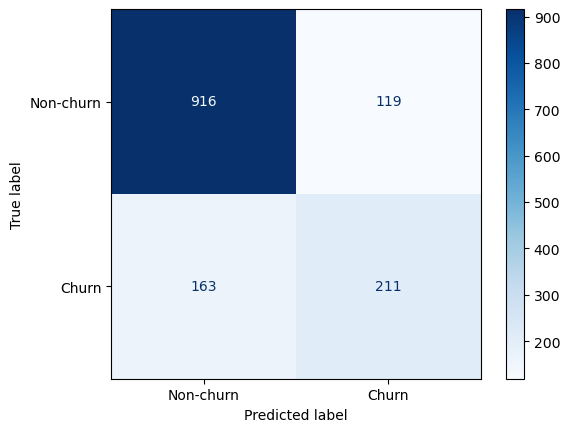

In [147]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-churn','Churn'])
disp.plot(cmap='Blues')
plt.show()

#### Classification Report

The classification report provides precision, recall, F1-score for each class. For churn prediction, recall is particularly important as it measures the proportion of actual churn cases that are correctly identified.

In [148]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



#### ROC_AUC Score

ROC-AUC measures the model's ability to distinguish between churn and non-churn across different thresholds.

In [149]:
roc_auc_score(y_test, y_prob)

0.8474179131468134

#### ROC curve

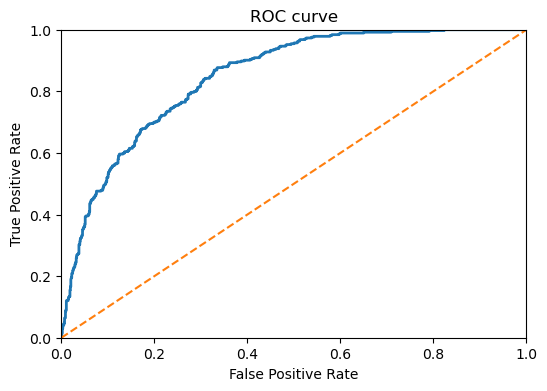

In [150]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr,tpr,linewidth=2,label='ROC curve')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.axis([0.0,1.0,0.0,1.0])
plt.show()

#### Interpretation of Results:

 - The model achieves good overall performance with an **ROC-AUC score** of **0.84**, indicating strong ability to distinguish between churn and non-churn customers.
 - Using the default threshold of 0.5, the model shows relatively low **recall** of **0.56** for churn, meaning a significant number of actual churn cases are not detected.
 - This is reflected in the confusion matrix, where **false negatives are 163**, indicating that these customers are incorrectly classified as non-churn and would not be targeted for retention efforts.
 - This suggests that while the model has good predictive power, **adjusting the classification threshold is necessary to improve churn detection**.

### 10. Approaches to Improve Model Performance

##### Handling Class Imbalance and Model Optimization
   To improve model performance on imbalanced data, different techniques such as threshold optimization and class-weighted training are explored and compared.

#### 10.1: Optimizing Classification Threshold

The default threshold for logistic regression is 0.5. However, in churn prediction problems it is often beneficial to adjust this threshold to improve recall(the model's ability to correctly identify churners). 

Using the ROC curve, we determine the optimal threshold by maximizing **Youden's J statistic** which balances the trade-off between true positive rate and false positive rate:
            **J = TPR - FPR** 

The threshold that maximizes this statistic provides an effective trade-off between identifying churners and controlling false positives, making it more suitable for business scenarios where detecting churn is critical.

In [151]:
J = tpr - fpr
best_index = np.argmax(J)
best_threshold = thresholds[best_index]

print('Best Threshold:', best_threshold)
print("TPR at best threshold:", tpr[best_index])
print("FPR at best threshold:", fpr[best_index])

Best Threshold: 0.19373879342541864
TPR at best threshold: 0.8770053475935828
FPR at best threshold: 0.3352657004830918


In [152]:
y_pred_new = (y_prob >= best_threshold).astype(int)

In [153]:
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.94      0.66      0.78      1035
           1       0.49      0.88      0.63       374

    accuracy                           0.72      1409
   macro avg       0.71      0.77      0.70      1409
weighted avg       0.82      0.72      0.74      1409



#### 10.2: Logistic Regression with Class Weights

To address the class imbalance, the model is retrained using **class_weight='balanced'** , which assigns higher importance to the minority class(churn). This allows the model to focus more on correctly identifying churn cases during training.

In [154]:
logreg_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

In [155]:
logreg_balanced.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method']),
                                                 ('num', StandardScaler(),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'TotalServices'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [156]:
y_pred_bal = logreg_balanced.predict(X_test)
y_prob_bal = logreg_balanced.predict_proba(X_test)[:,1]

In [157]:
cm_bal = confusion_matrix(y_test, y_pred_bal)
cm_bal

array([[760, 275],
       [ 85, 289]], dtype=int64)

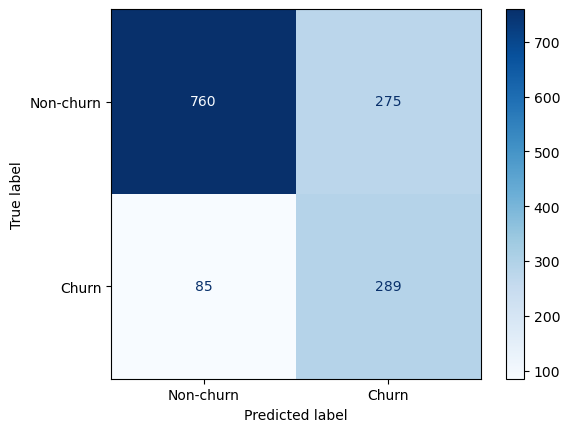

In [158]:
disp_bal = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=['Non-churn','Churn'])
disp_bal.plot(cmap='Blues')
plt.show()

In [159]:
print(classification_report(y_test,y_pred_bal))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.77      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [160]:
roc_auc_score(y_test, y_prob_bal)

0.8470355731225298

#### Comparison of Approaches

 - The baseline model showed low recall for churn(0.56), missing many at-risk customers.
 - Applying class weights improved recall to 0.77 by giving higher importance to the minority class during training.
 - However, threshold optimization provided the best performance in recall, achieving a value of 0.88 while maintaining reasonable precision.
 - This indicates that the model already had strong predictive capability(as reflected by ROC-AUC), and adjusting the decision threshold was more effective than modifying class weights.

### 11: Identify the top drivers of Churn

Feature importance is derived from logistic regression coefficients.

The magnitude (absolute value) of the coefficient indicates the strength of the feature's impact, while the sign indicates the direction:
 - Positive coefficient -> increases likelihood of churn
 - Negative coefficient -> decreases likelihood of churn

Features are ranked based on absolute coefficient values to identify the most influential drivers.

In [161]:
processor = logreg_pipeline.named_steps['preprocessor']

# Get categorical features name
ohe = processor.named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(categorical_cols)

# Combine with numerical features
all_features = list(encoded_cat_features) + numerical_cols

# Get model coefficients
coefficients = logreg_pipeline.named_steps['model'].coef_[0]

In [162]:
# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coefficients
})

In [163]:
feature_importance['abs_coef'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='abs_coef', ascending=False)

In [164]:
top_features = feature_importance.head(10)
top_features

,Feature,Coefficient,abs_coef
16,Monthly Charges,1.684462,1.684462
3,Dependents_Yes,-1.630316,1.630316
10,Contract_Two year,-1.351702,1.351702
4,Phone Service_Yes,-0.953276,0.953276
15,Tenure Months,-0.826404,0.826404
9,Contract_One year,-0.744621,0.744621
17,TotalServices,-0.723269,0.723269
8,Internet Service_No,0.714721,0.714721
5,Multiple Lines_No phone service,0.693179,0.693179
7,Internet Service_Fiber optic,-0.434427,0.434427


In [165]:
# Sort features by coefficient values for better visualization
plot_df = feature_importance.sort_values(by='Coefficient', ascending=False)

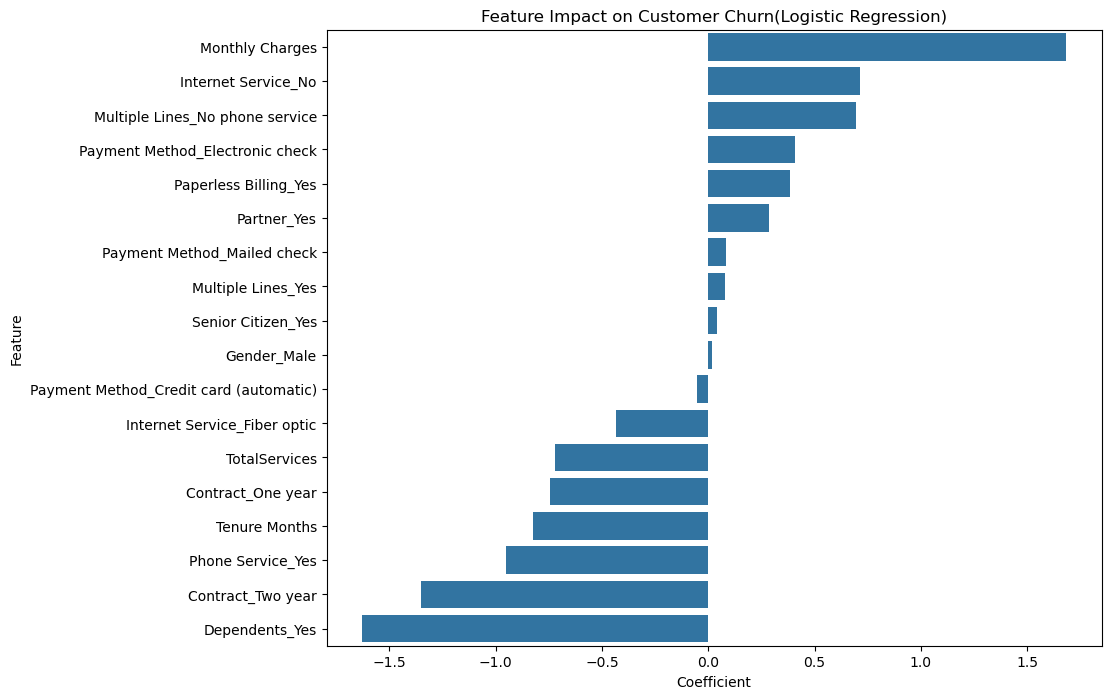

In [166]:
# plot the features 
plt.figure(figsize=(10,8))
sns.barplot(x='Coefficient', y='Feature', data=plot_df)
plt.title('Feature Impact on Customer Churn(Logistic Regression)')
plt.show()

### Business Insights:

 - Customers with **high monthly charges** are significantly **more likely to churn**, indicating price sensitivity.
 - Customers with **longer tenure** show a much **lower likelihood of churn**, suggesting that customer loyalty increases over time.
 - Customers with **more subscribed services(higher total services)** are **less likely to churn**, indicating that deeper engagement with services improves retention.
 - Customers on **long-term contracts(especially two-year plans)** have a significantly **lower churn risk** compared to those on month-to-month contracts.
 - Customers **with dependents** are **less likely to churn**, which may indicate more stable or long-term service usage patterns.
 - Customers using **electronic check** as a payment method show a **higher likelihood of churn**.

### Strategic Recommendations:

These insights can help the business design targeted retention strategies, such as offering discounts to high-charge customers, encouraging long-term contracts, and focusing retention efforts on customers with a higher predicted likelihood of churn.

### Conclusion:

This project demonstartes the development of a machine learning model to predict customer churn and identify key factors influencing churn behavior.

The baseline logistic regression model achieved good overall performance (ROC-AUC ~ 0.84), but had lower recall for churn. By applying threshold optimization and class-weighted learning, model performance was improved, with threshold tuning providing the best balance between recall and precision. 

Overall, this analysis highlights how machine learning can be used not only for prediction but also to generate actionable insights that support business decision-making.